In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Figure Size (Default is too small)
plt.rcParams["figure.figsize"] = (15, 9)

**Particle motion on the f-plane (constant Coriolis parameter) in a wavy geopotential field

In [ ]:
#Establish arrays
delta_t = 10. #timestep: seconds
t_filt = 0.01 #numerical time filter coefficient
t_days=10. #run time: days
s_per_day= 86400. #seconds in a day
s_per_hour=3600.
t_sec = t_days*s_per_day
n_t = int(t_sec/delta_t)
t=np.linspace(0.,t_sec,n_t) #time values: s
t_in_hours=t/s_per_hour
x=np.zeros(n_t)
y=np.zeros(n_t)
u=np.zeros(n_t)
v=np.zeros(n_t)
speed=np.zeros(n_t)
geopot=np.zeros(n_t)
KE=np.zeros(n_t)
PE=np.zeros(n_t)
u_geo=np.zeros(n_t)
v_geo=np.zeros(n_t)

#Constants
g = 9.81 #acceleration of gravity: m/s^2
f_coriolis=1.e-4 #Coriolis parameter: 1/s
U_geos = 10. #Zonal geostrophic wind to define y-directed force: m/s
force_y= U_geos*f_coriolis #imposed northward force: m/s^2
V_geos_mag = 5. #Amplitude of geostrophic meridional wind to define y-directed force: m/s
force_x_mag = V_geos_mag*f_coriolis
L_wave = 10000. #Zonal wavelength of wavy jet: km
L_wave = L_wave * 1.e3 #Zonal wavelength in m: m
drag=0. #drag: 1/s

#Step velocity & position forward in time
#Start at origin with geostrophic velocity
#Geostrophic U = constant U_geos
#Geostrophic V = V_geos_mag*cosine(2πx/L_wave)

#Initial conditions: geostropic eastward velocity north of origin
u[0]=U_geos
v[0]=V_geos_mag
x[0]=0.
y[0]=0.

#For first time step take forward step
v[1]=v[0]+delta_t*(force_y-u[0]*f_coriolis-drag*v[0])
u[1]=u[0]+delta_t*(-force_x_mag+v[0]*f_coriolis-drag*u[0])
x[1]=x[0]+delta_t*u[0]
y[1]=y[0]+delta_t*v[0]
speed[0] = np.sqrt(u[0]**2+v[0]**2)
speed[1] = np.sqrt(u[1]**2+v[1]**2)
geopot[0] = 0.
geopot[1] = f_coriolis/g*(-y[1]*U_geos\
            + V_geos_mag*L_wave/(2.*np.pi)*np.sin(2.*np.pi*x[1]/L_wave))
KE[0]=.5*(u[0]**2+v[0]**2)
KE[1]=.5*(u[1]**2+v[1]**2)
u_geo[0]=U_geos
v_geo[0]=V_geos_mag*np.cos(2.*np.pi*x[1]/L_wave)
u_geo[1]=U_geos
v_geo[1]=V_geos_mag*np.cos(2.*np.pi*x[1]/L_wave)
#For i_t>1 use leapfrog
for i_t in range (2,n_t):
    v[i_t]=v[i_t-2]+2.*delta_t*(force_y-u[i_t-1]*f_coriolis-drag*v[i_t-1])
    u[i_t]=u[i_t-2]+2.*delta_t*(-force_x_mag*np.cos(2.*np.pi*x[i_t-1]/L_wave)\
                                      +v[i_t-1]*f_coriolis-drag*u[i_t-1])
    x[i_t]=x[i_t-2]+2.*delta_t*u[i_t-1]
    y[i_t]=y[i_t-2]+2.*delta_t*v[i_t-1]
    speed[i_t] = np.sqrt(u[i_t]**2+v[i_t]**2) #speed: m/s
    geopot[i_t]= f_coriolis/g*(-y[i_t]*U_geos\
            + V_geos_mag*L_wave/(2.*np.pi)*np.sin(2.*np.pi*x[i_t]/L_wave))

    #Asselin time filter for velocity
    v[i_t-1]=v[i_t-1] +t_filt*(v[i_t-2]+v[i_t]-2.*v[i_t-1])
    u[i_t-1]=u[i_t-1] +t_filt*(u[i_t-2]+u[i_t]-2.*u[i_t-1])

    KE[i_t]=.5*(u[i_t]**2+v[i_t]**2)
    u_geo[i_t]=U_geos
    v_geo[i_t]=V_geos_mag*np.cos(2.*np.pi*x[i_t]/L_wave)


Plots

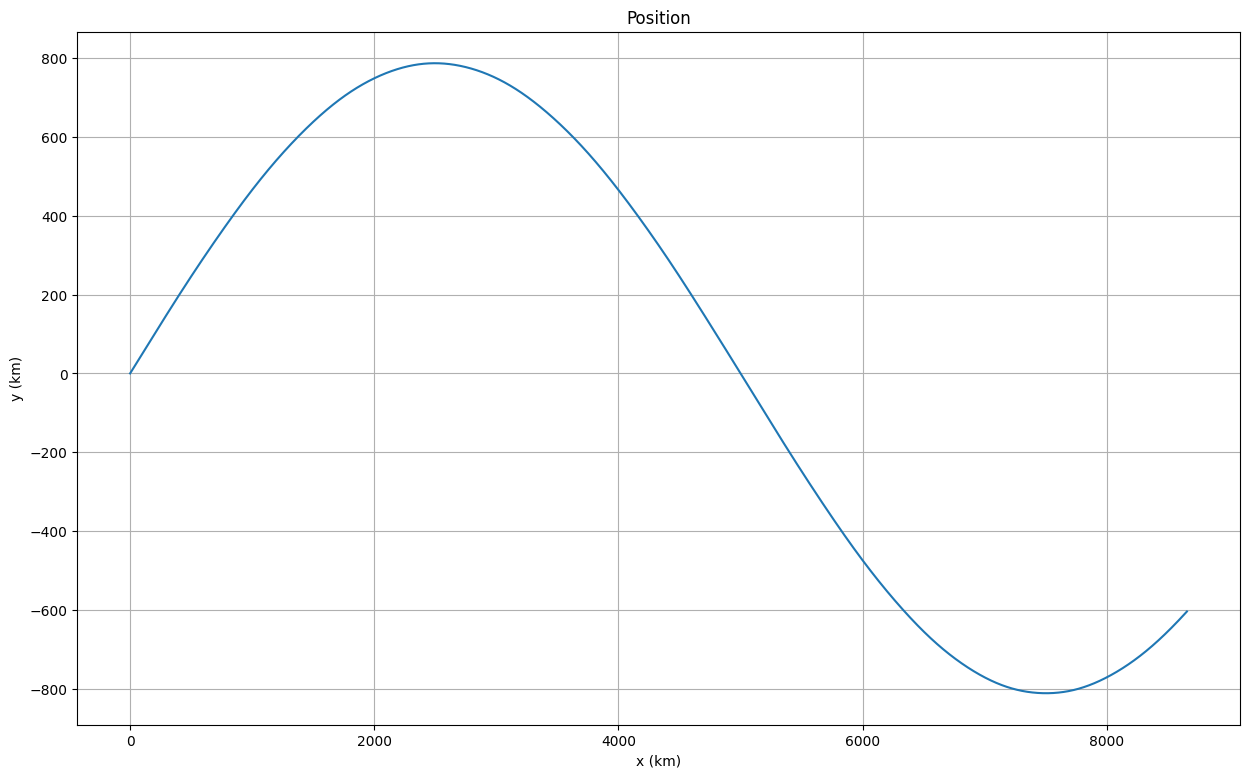

In [ ]:
#Particle trajectory (y versus x)
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('y (km)')
ax2.set_xlabel('x (km)')
ax2.set_title('Position')
line, = ax2.plot(x*1.e-3,y*1.e-3)
plt.grid()
plt.show()

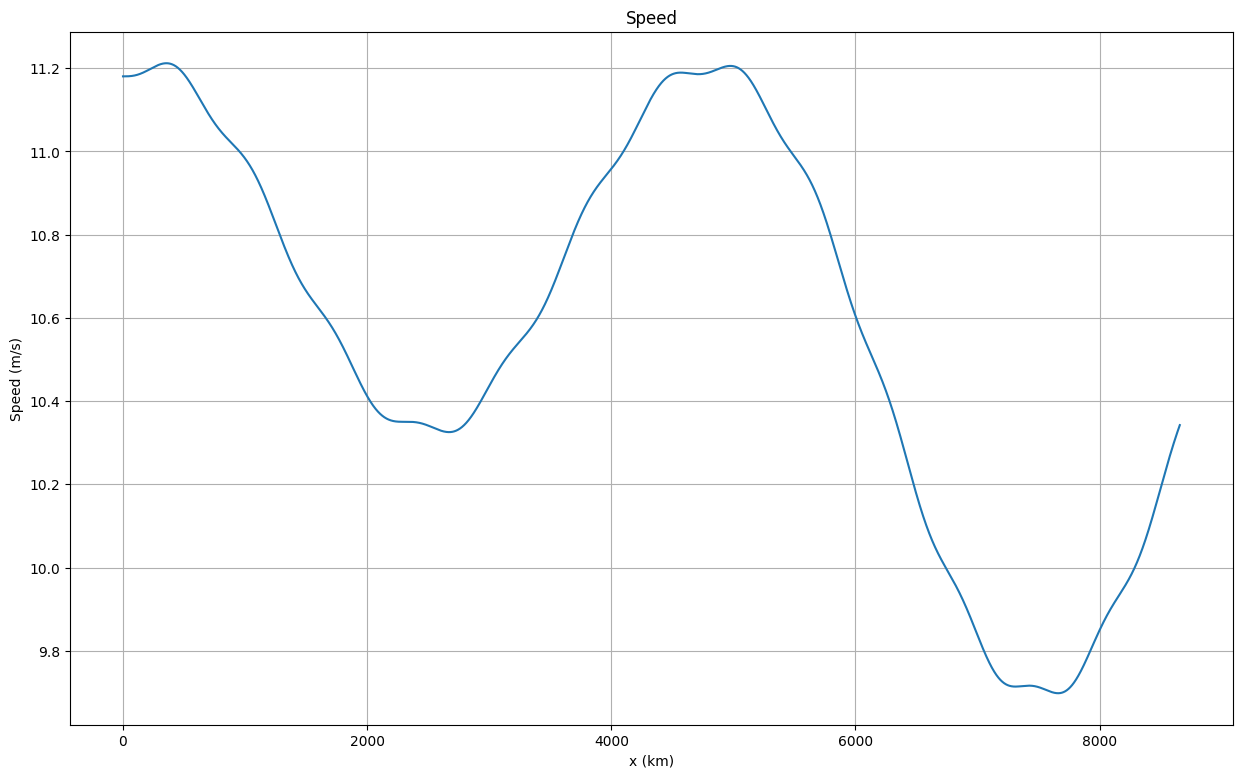

In [ ]:
#Particle speed versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('Speed (m/s)')
ax2.set_xlabel('x (km)')
ax2.set_title('Speed')
line, = ax2.plot(x*1.e-3,speed)
plt.grid()
plt.show()

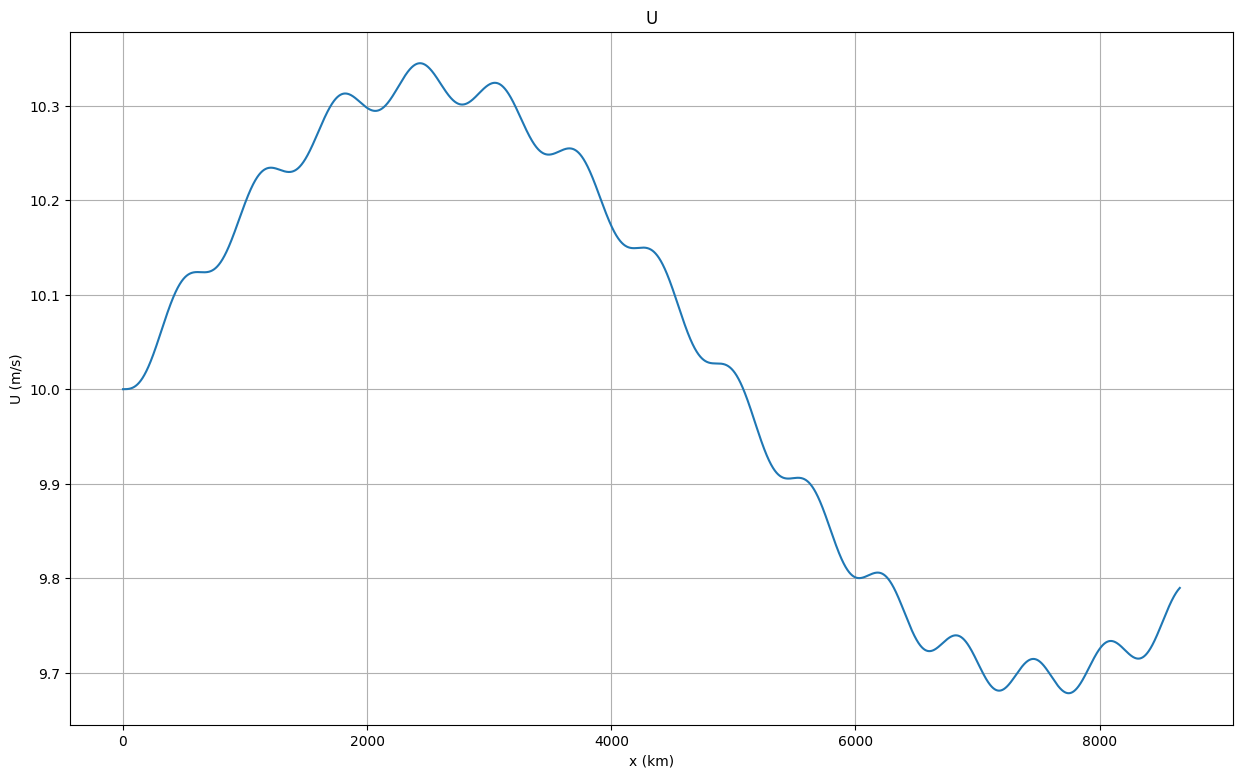

In [ ]:
#Particle u versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('U (m/s)')
ax2.set_xlabel('x (km)')
ax2.set_title('U')
line, = ax2.plot(x*1.e-3,u)
plt.grid()
plt.show()


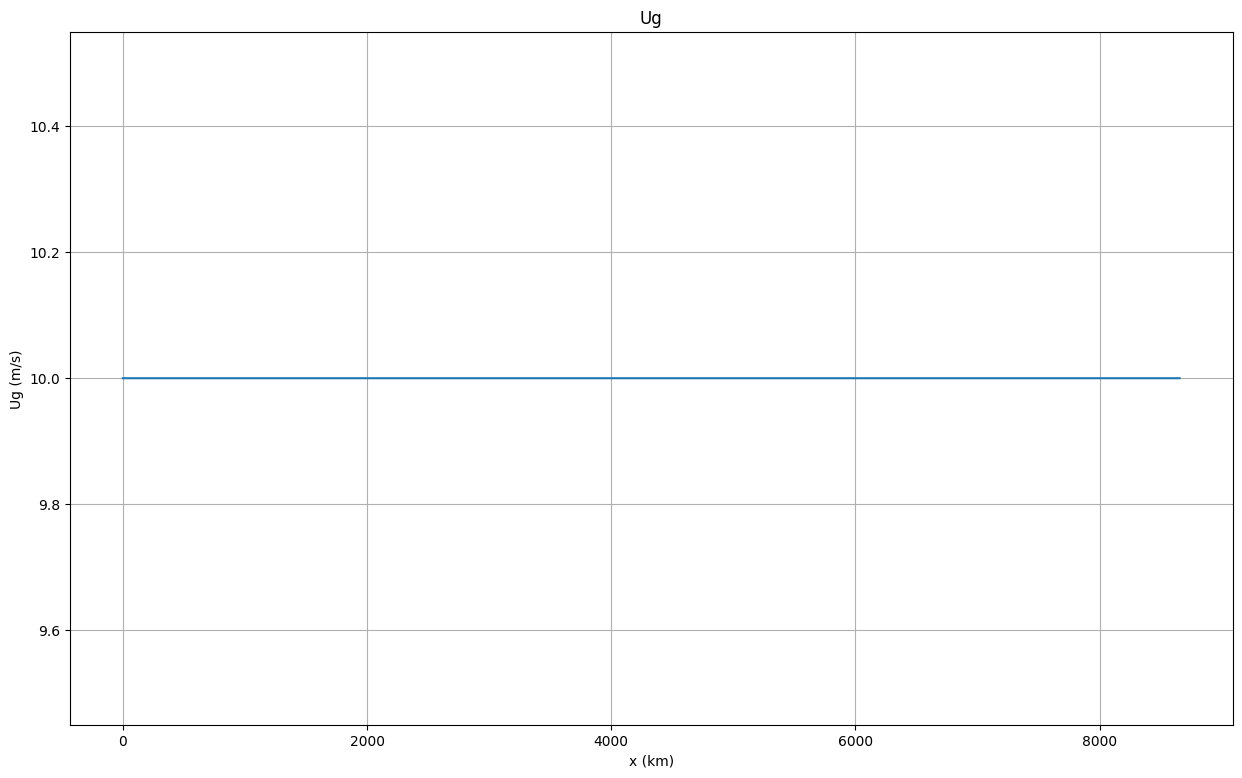

In [ ]:
#Particle u versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('Ug (m/s)')
ax2.set_xlabel('x (km)')
ax2.set_title('Ug')
line, = ax2.plot(x*1.e-3,u_geo)
plt.grid()
plt.show()


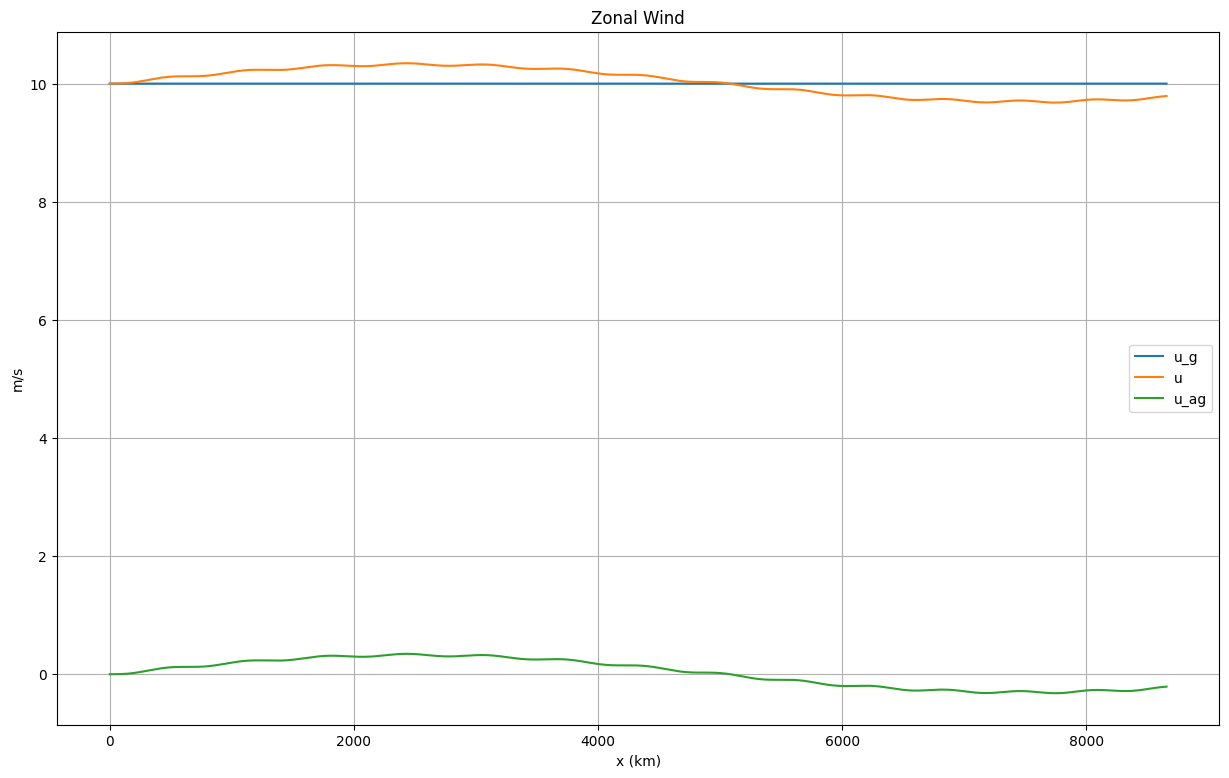

In [ ]:
#Particle u versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('m/s')
ax2.set_xlabel('x (km)')
ax2.set_title('Zonal Wind')
line, = ax2.plot(x*1.e-3,u_geo, label='u_g')
line, = ax2.plot(x*1.e-3,u, label='u')
line, = ax2.plot(x*1.e-3,u-u_geo, label='u_ag')
plt.legend()
plt.grid()
plt.show()


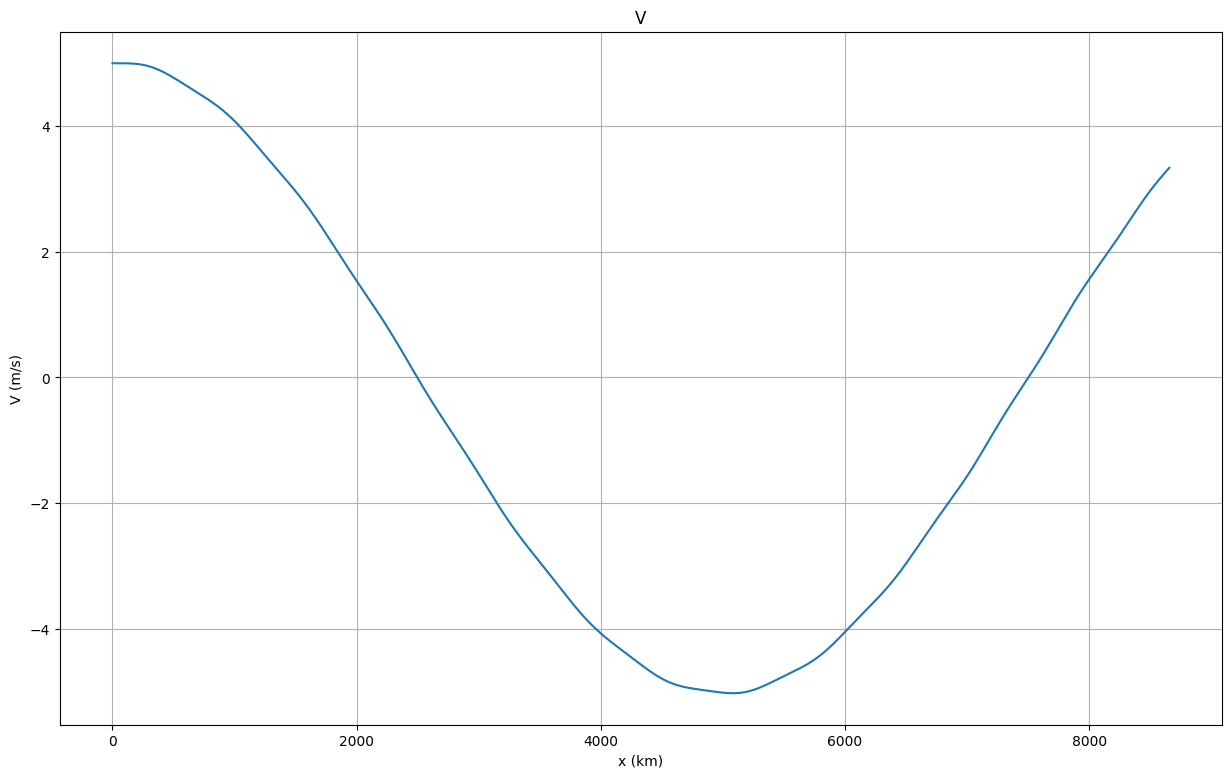

In [ ]:
#Particle v versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('V (m/s)')
ax2.set_xlabel('x (km)')
ax2.set_title('V')
line, = ax2.plot(x*1.e-3,v)
plt.grid()
plt.show()


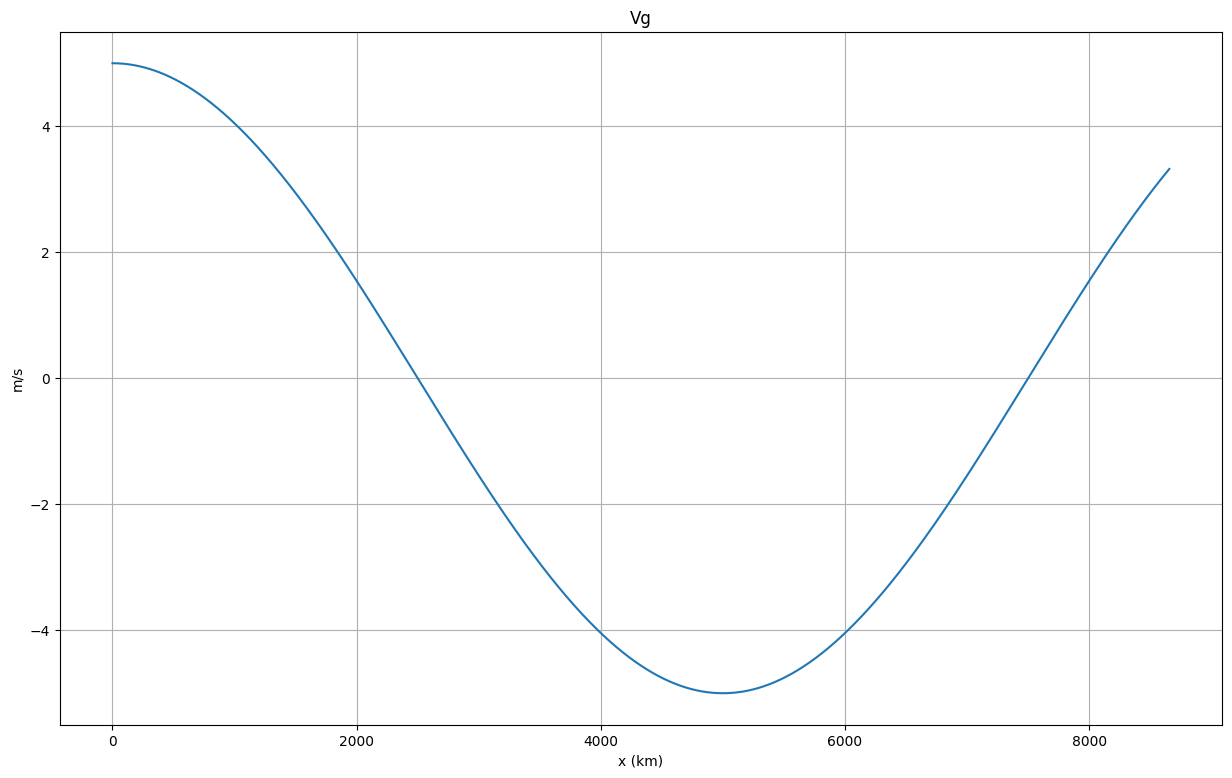

In [ ]:
#Particle u versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('m/s')
ax2.set_xlabel('x (km)')
ax2.set_title('Vg')
line, = ax2.plot(x*1.e-3,v_geo)
plt.grid()
plt.show()


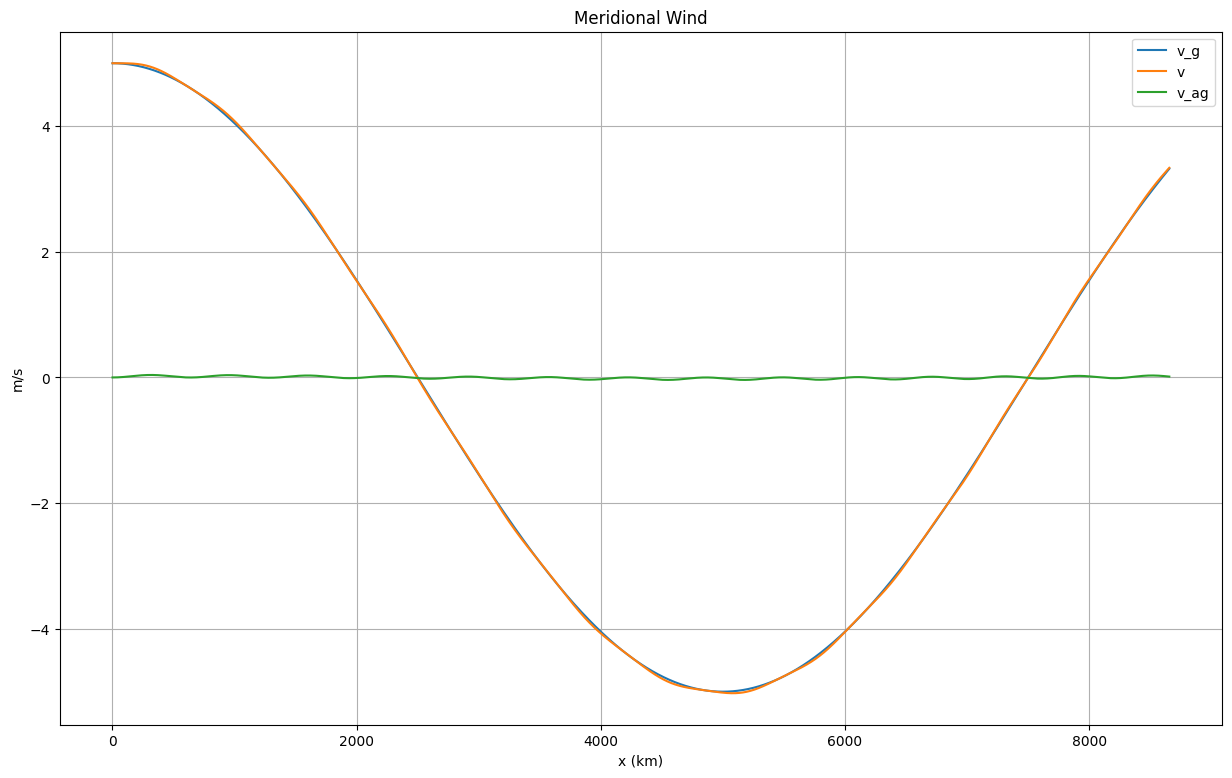

In [ ]:
#Particle u versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('m/s')
ax2.set_xlabel('x (km)')
ax2.set_title('Meridional Wind')
line, = ax2.plot(x*1.e-3,v_geo, label='v_g')
line, = ax2.plot(x*1.e-3,v, label='v')
line, = ax2.plot(x*1.e-3,v-v_geo, label='v_ag')
plt.legend()
plt.grid()
plt.show()


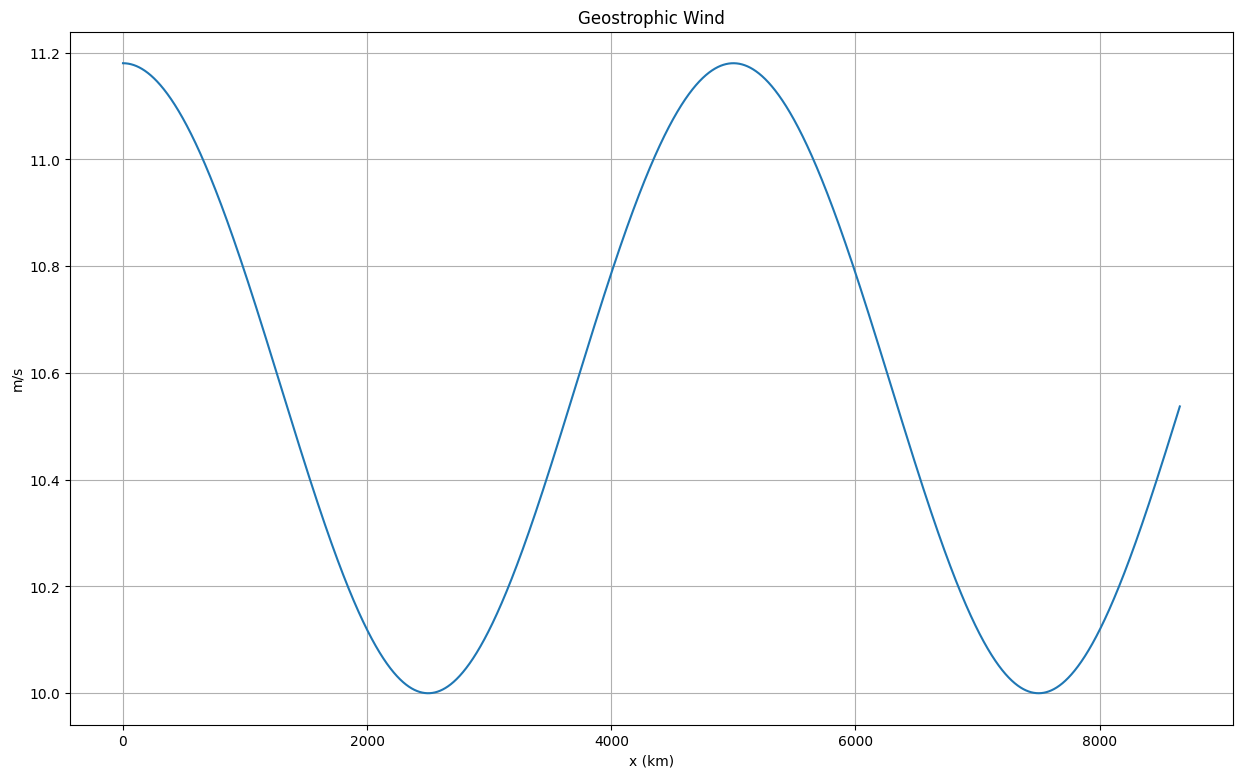

In [ ]:
wnd_g = np.sqrt(u_geo**2+v_geo**2)
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('m/s')
ax2.set_xlabel('x (km)')
ax2.set_title('Geostrophic Wind')
line, = ax2.plot(x*1.e-3,wnd_g)
plt.grid()
plt.show()

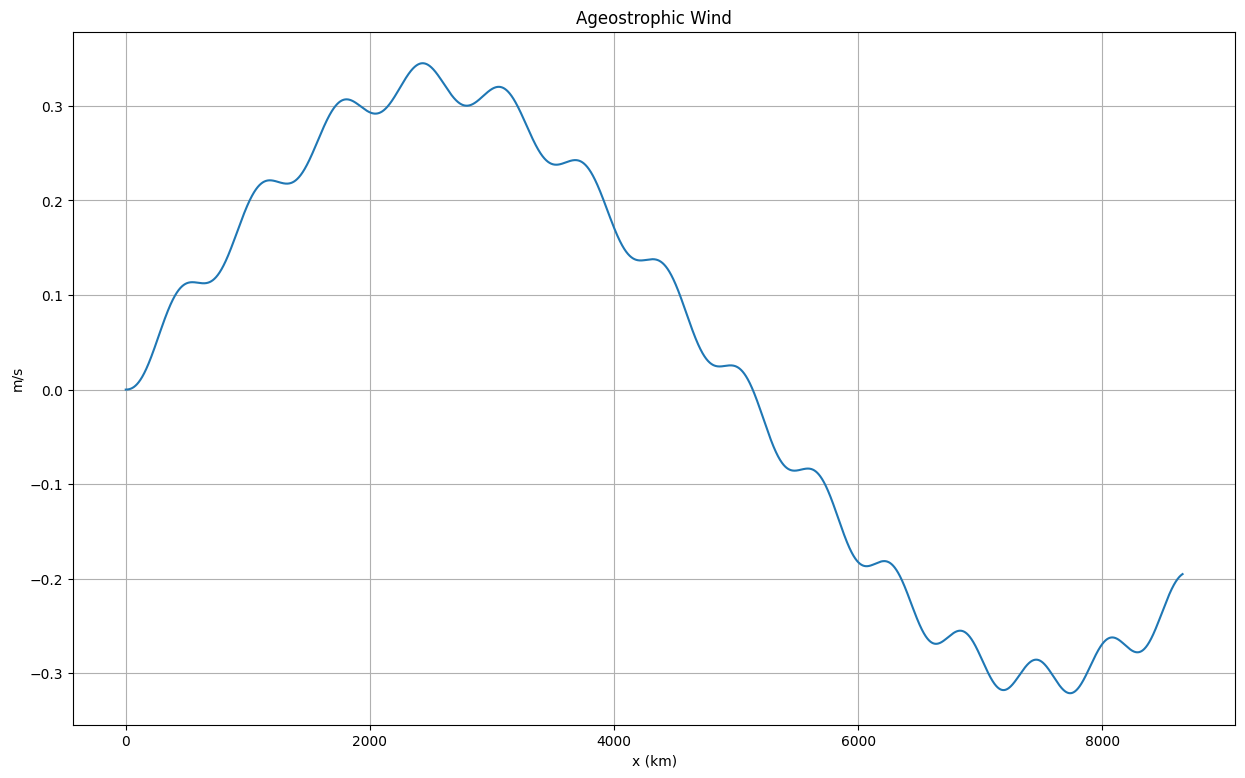

In [ ]:
wnd = np.sqrt(u**2+v**2)
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('m/s')
ax2.set_xlabel('x (km)')
ax2.set_title('Ageostrophic Wind')
line, = ax2.plot(x*1.e-3,wnd-wnd_g)
plt.grid()
plt.show()

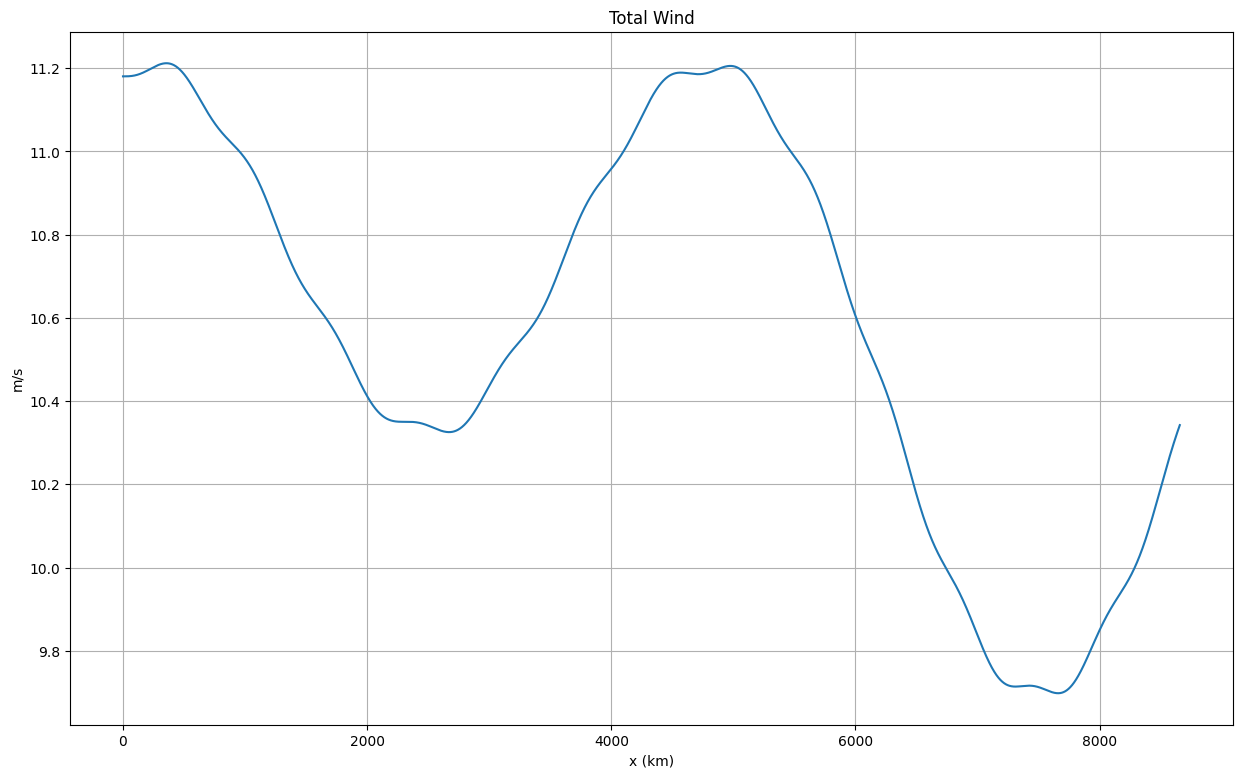

In [ ]:
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('m/s')
ax2.set_xlabel('x (km)')
ax2.set_title('Total Wind')
line, = ax2.plot(x*1.e-3,wnd)
plt.grid()
plt.show()

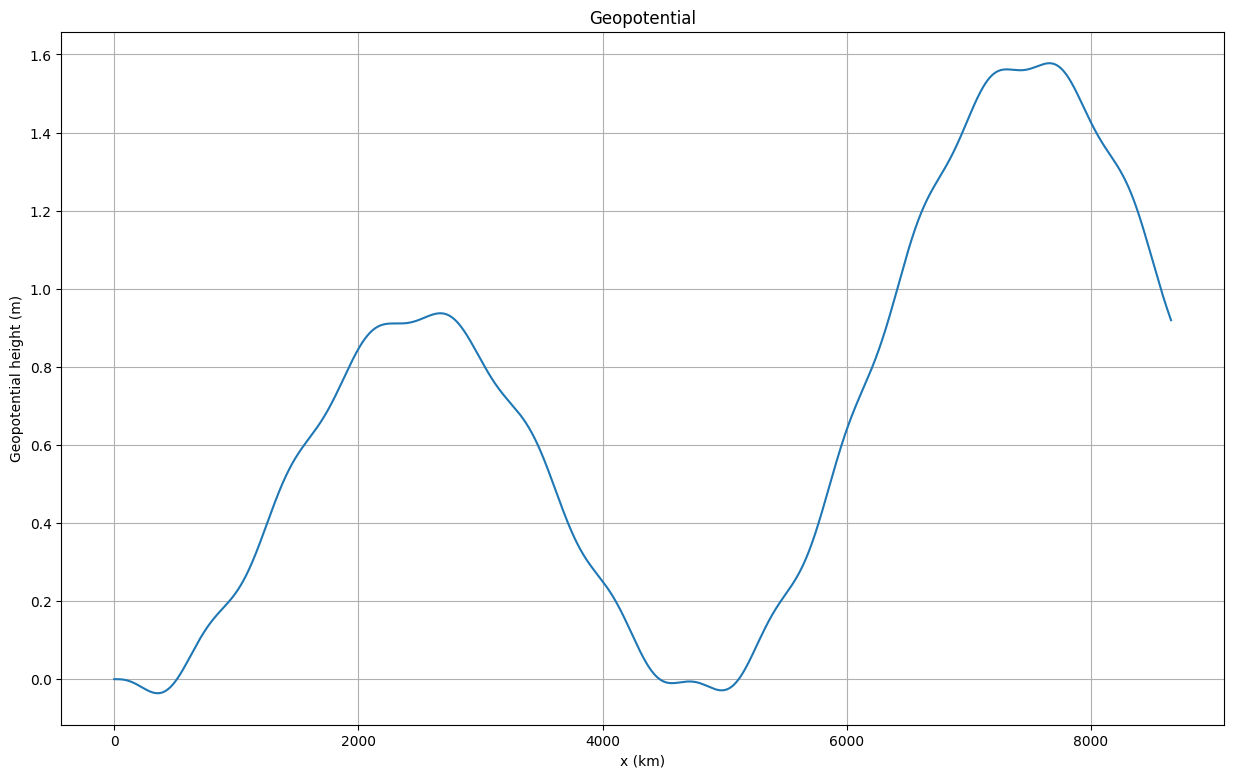

In [ ]:
#Geopotential height at particle position versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('Geopotential height (m)')
ax2.set_xlabel('x (km)')
ax2.set_title('Geopotential')
line, = ax2.plot(x*1.e-3,geopot)
plt.grid()
plt.show()

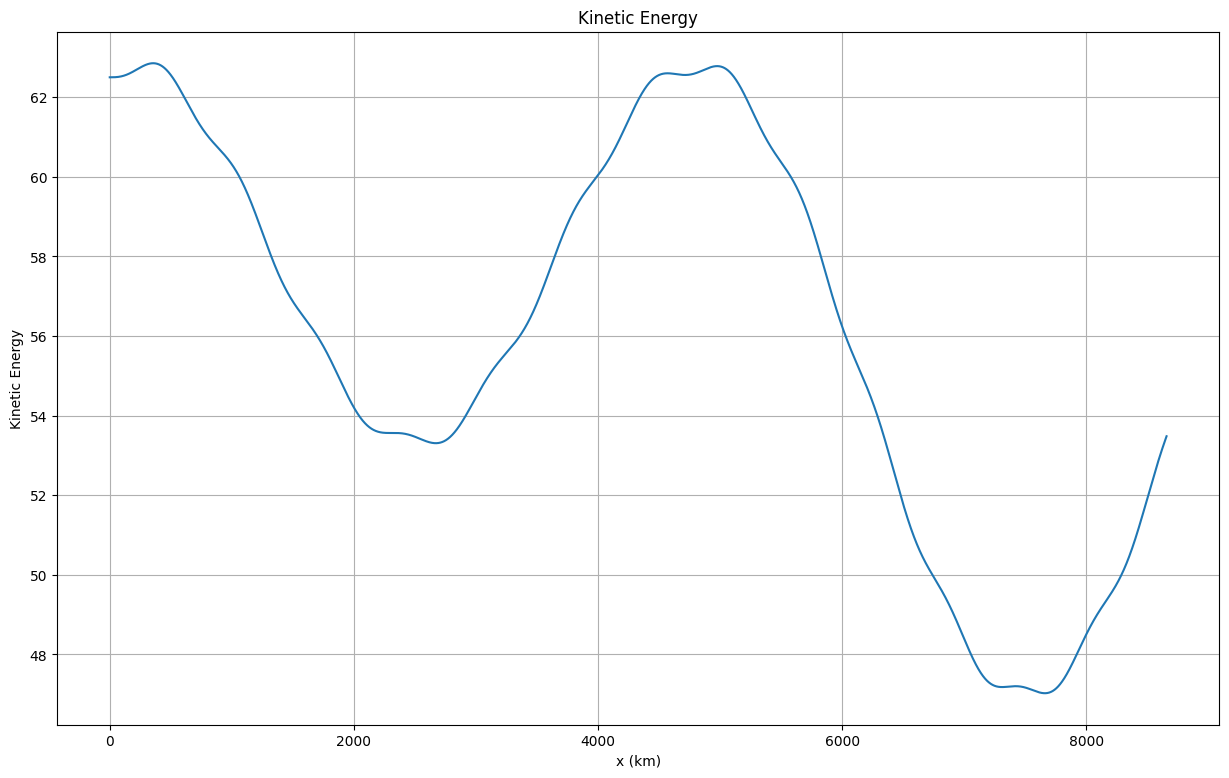

In [ ]:
#Geopotential height at particle position versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('Kinetic Energy')
ax2.set_xlabel('x (km)')
ax2.set_title('Kinetic Energy')
line, = ax2.plot(x*1.e-3,KE)
#plt.ylim(0,10)
plt.grid()
plt.show()

In [ ]:
# Calculate PE
PE = geopot*g
PE


array([ 0.00000000e+00, -3.28986744e-11, -2.63189440e-10, ...,
        9.02047574e+00,  9.01964000e+00,  9.01880445e+00])

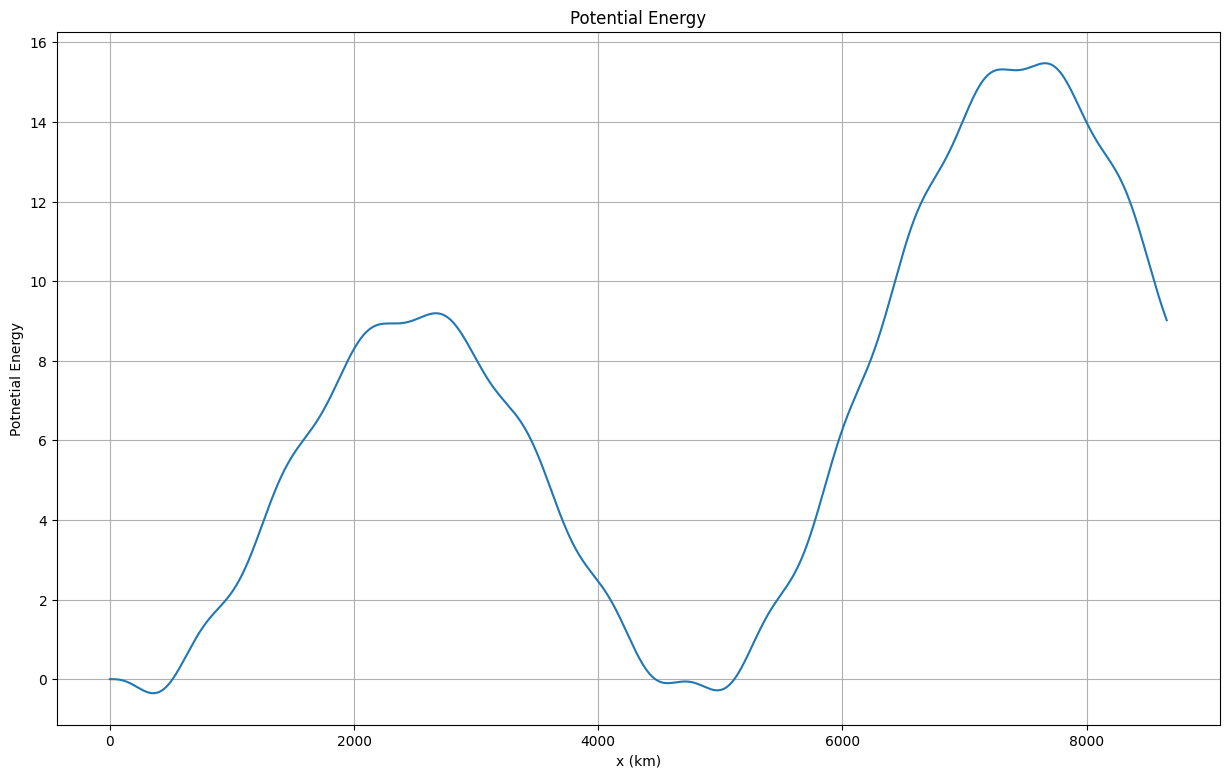

In [ ]:
#Geopotential height at particle position versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('Potnetial Energy')
ax2.set_xlabel('x (km)')
ax2.set_title('Potential Energy')
line, = ax2.plot(x*1.e-3,PE)
#plt.ylim(0,10)
plt.grid()
plt.show()

In [ ]:
# Calculate TE
TE = PE+KE
TE


array([62.5       , 62.5       , 62.5       , ..., 62.49998057,
       62.49998057, 62.49998057])

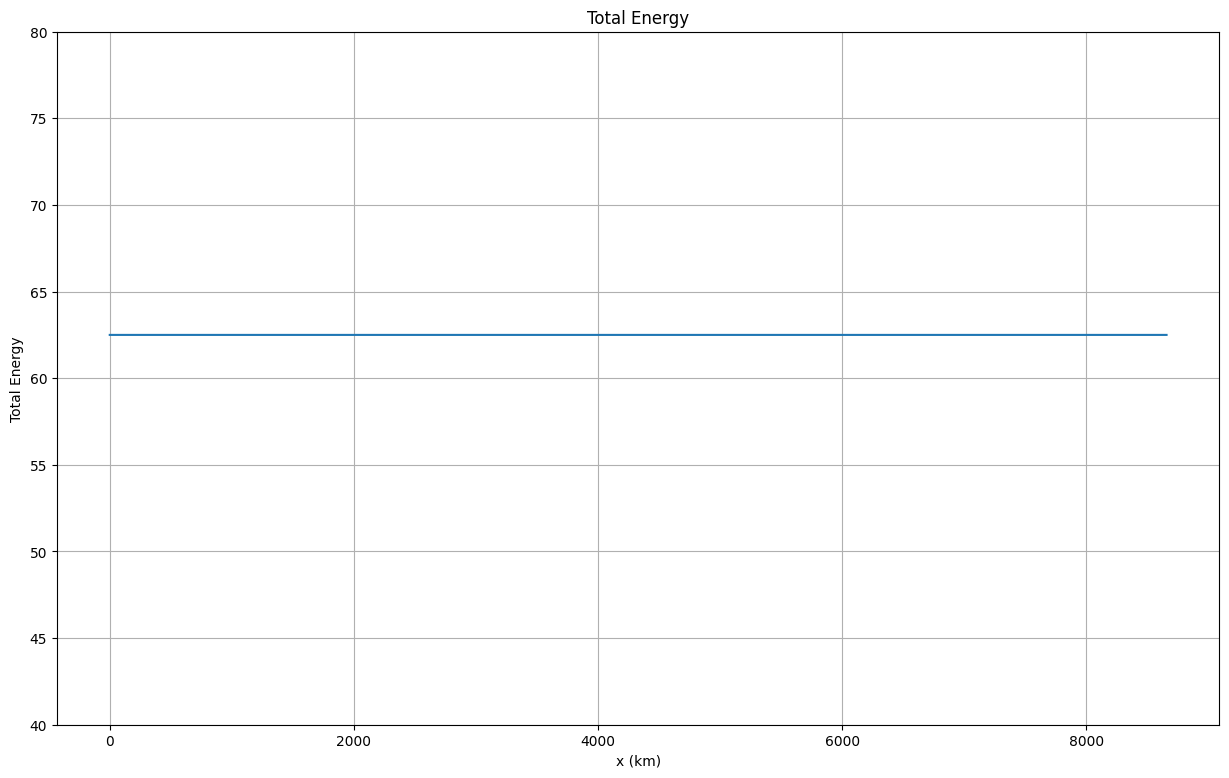

In [ ]:
#Geopotential height at particle position versus x
fig = plt.figure()
ax2 = fig.add_subplot(111)
ax2.set_ylabel('Total Energy')
ax2.set_xlabel('x (km)')
ax2.set_title('Total Energy')
line, = ax2.plot(x*1.e-3,TE)
plt.ylim(40,80)
plt.grid()
plt.show()

In [ ]:
TE

array([62.5       , 62.5       , 62.5       , ..., 62.49998057,
       62.49998057, 62.49998057])